# Scalability Analysis

Plots and per-model timing metrics from `scalability_results1.csv` (the complete 8-model run).

**Produces:**
1. `cum_train_evolution.{png,pdf}` &mdash; cumulative training time vs `n`, one line per model
2. `cum_infer_evolution.{png,pdf}` &mdash; cumulative inference time vs `n`, one line per model
3. `mean_build_time.{png,pdf}` + `build_time_summary.csv` &mdash; average per-product graph build time per model
4. **Epochs analysis** &mdash; mean epochs to train one product, and average time per epoch, per model

> The epochs analysis needs `epochs_trained` / `s_per_epoch` columns. `results1.csv` does not
> carry them yet, so the relevant cell falls back to `results.csv` (which does) and prints a
> notice. Once you log epochs into `results1.csv`, the fallback simply stops triggering.

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

# Resolve the folder this notebook lives in (works as .ipynb or via __file__).
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

CSV = os.path.join(HERE, "scalability_results.csv")
df = pd.read_csv(CSV)
print(f"Loaded {len(df)} rows from {os.path.basename(CSV)}")
print("Columns:", list(df.columns))
df.head()

Loaded 4000 rows from scalability_results.csv
Columns: ['variant', 'product_id', 'store_id', 'n', 'build_s', 'train_s', 'infer_s', 'cum_build_s', 'cum_train_s', 'cum_infer_s', 'product_peak_gpu_mb', 'product_peak_ram_mb', 'cum_peak_gpu_mb', 'cum_peak_ram_mb', 'epochs_trained', 's_per_epoch']


,variant,product_id,store_id,n,build_s,train_s,infer_s,cum_build_s,cum_train_s,cum_infer_s,product_peak_gpu_mb,product_peak_ram_mb,cum_peak_gpu_mb,cum_peak_ram_mb,epochs_trained,s_per_epoch
0,gcn_lstm,27,6269,1,3.230,77.441,0.447,3.230,77.441,0.447,0.0,10.75,0.0,10.75,153,0.506150
1,gcn_lstm,55,6269,2,2.355,65.362,0.381,5.586,142.803,0.827,0.0,0.00,0.0,10.75,152,0.430014
2,gcn_lstm,71,6269,3,5.357,91.871,0.738,10.943,234.674,1.566,0.0,12.00,0.0,12.00,169,0.543617
3,gcn_lstm,116,6269,4,2.722,47.545,0.505,13.665,282.219,2.071,0.0,0.00,0.0,12.00,104,0.457160
4,gcn_lstm,128,6269,5,4.053,63.966,0.408,17.718,346.185,2.479,0.0,0.00,0.0,12.00,107,0.597817


In [19]:
# Stable, readable ordering: baselines first, then graph2vec, gcn, gat.
ORDER = ["lstm_baseline", "mlp_baseline",
         "graph2vec_lstm", "graph2vec_mlp",
         "gcn_lstm", "gcn_mlp",
         "gat_lstm", "gat_mlp"]
variants = [v for v in ORDER if v in df["variant"].unique()]
variants += [v for v in df["variant"].unique() if v not in variants]  # any extras

cmap   = plt.get_cmap("tab10")
colors = {v: cmap(i % 10) for i, v in enumerate(variants)}
variants

['lstm_baseline',
 'mlp_baseline',
 'graph2vec_lstm',
 'graph2vec_mlp',
 'gcn_lstm',
 'gcn_mlp',
 'gat_lstm',
 'gat_mlp']

In [20]:
def line_plot(ycol, ylabel, title, outname):
    """One line per model; saves png+pdf into HERE and shows inline."""
    fig, ax = plt.subplots(figsize=(11, 6))
    for v in variants:
        sub = df[df["variant"] == v].sort_values("n")
        ax.plot(sub["n"], sub[ycol], label=v, color=colors[v], linewidth=1.6)
    ax.set_xlabel("Number of products processed (n)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, ncol=2)
    fig.tight_layout()
    for ext in ("png", "pdf"):
        path = os.path.join(HERE, f"{outname}.{ext}")
        fig.savefig(path, dpi=150, bbox_inches="tight")
        print(f"Saved {path}")
    plt.show()

## 1. Cumulative training time evolution

Saved c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_train_evolution.png
Saved c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_train_evolution.pdf


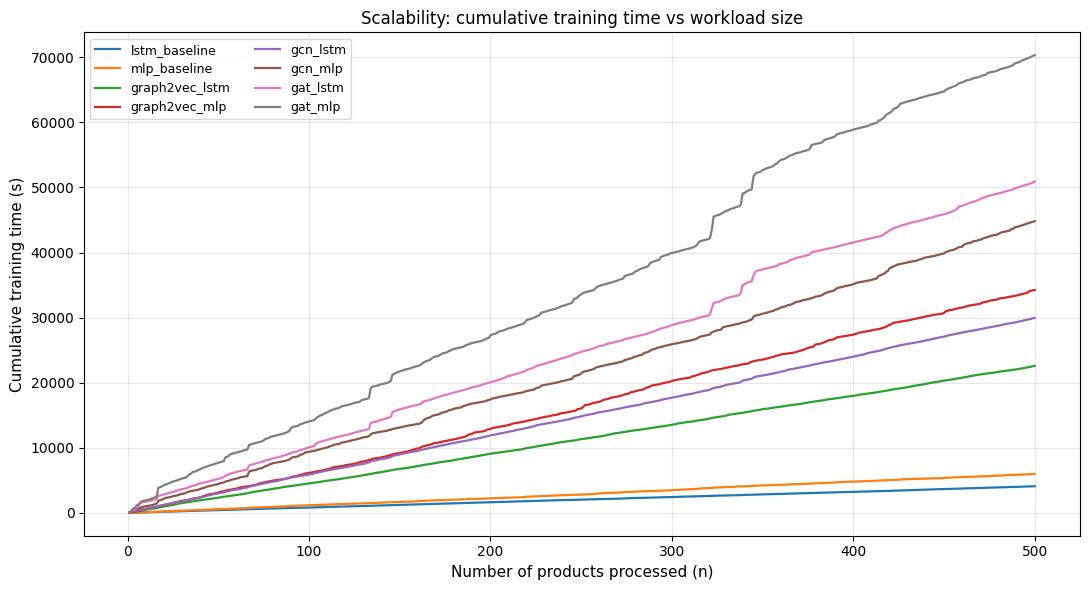

In [21]:
line_plot(
    "cum_train_s",
    "Cumulative training time (s)",
    "Scalability: cumulative training time vs workload size",
    "cum_train_evolution",
)

In [22]:
import os
import numpy as np
import pandas as pd

# ── load ──────────────────────────────────────────────────────────────────────
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()

df = pd.read_csv(os.path.join(HERE, "scalability_results.csv"))

ORDER = ["lstm_baseline", "mlp_baseline",
         "graph2vec_lstm", "graph2vec_mlp",
         "gcn_lstm", "gcn_mlp",
         "gat_lstm", "gat_mlp"]
variants = [v for v in ORDER if v in df["variant"].unique()]

# ── aggregate ─────────────────────────────────────────────────────────────────
BASELINE = {"lstm_baseline", "mlp_baseline"}   # no graph-build step

rows = []
for v in variants:
    g = df[df["variant"] == v]
    last = g.loc[g["n"].idxmax()]              # row at N = 500
    rows.append({
        "variant":      v,
        "mean_build_s": None if v in BASELINE else g["build_s"].mean(),
        "mean_train_s": g["train_s"].mean(),
        "std_train_s":  g["train_s"].std(),
        "mean_infer_s": g["infer_s"].mean(),
        "cum_train_s":  last["cum_train_s"],
        "cum_infer_s":  last["cum_infer_s"],
        "N":            int(last["n"]),
    })

stats = pd.DataFrame(rows)

# ── LaTeX ─────────────────────────────────────────────────────────────────────
LABEL_MAP = {
    "lstm_baseline":  "lstm\\_baseline",
    "mlp_baseline":   "mlp\\_baseline",
    "graph2vec_lstm": "graph2vec\\_lstm",
    "graph2vec_mlp":  "graph2vec\\_mlp",
    "gcn_lstm":       "gcn\\_lstm",
    "gcn_mlp":        "gcn\\_mlp",
    "gat_lstm":       "gat\\_lstm",
    "gat_mlp":        "gat\\_mlp",
}

def fmt(val, decimals=2, dash_if_none=True):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return r"\textemdash" if dash_if_none else "---"
    return f"{val:.{decimals}f}"

lines = []
lines.append(r"\begin{table}[ht]")
lines.append(r"  \centering")
lines.append(r"  \caption{Per-model scalability statistics over $N=500$ products: "
             r"mean and std of per-product training time, "
             r"mean per-product inference time, and cumulative totals.}")
lines.append(r"  \label{tab:scalability_stats}")
lines.append(r"  \small")
lines.append(r"  \begin{tabular}{lrrrrrrr}")
lines.append(r"    \toprule")
lines.append(r"    \textbf{Model variant} & \textbf{Mean build (s)} & \textbf{Mean train (s)} "
             r"& \textbf{Std train (s)} & \textbf{Mean infer (s)} "
             r"& \textbf{Cum.\ train (s)} & \textbf{Cum.\ infer (s)} & $N$ \\")
lines.append(r"    \midrule")

for _, row in stats.iterrows():
    label = LABEL_MAP.get(row["variant"], row["variant"].replace("_", r"\_"))
    cells = [
        label,
        fmt(row["mean_build_s"]),
        fmt(row["mean_train_s"]),
        fmt(row["std_train_s"]),
        fmt(row["mean_infer_s"], decimals=3),
        fmt(row["cum_train_s"], decimals=0),
        fmt(row["cum_infer_s"], decimals=0),
        str(row["N"]),
    ]
    lines.append("    " + " & ".join(cells) + r" \\")

lines.append(r"    \bottomrule")
lines.append(r"  \end{tabular}")
lines.append(r"\end{table}")

latex = "\n".join(lines)
print(latex)

# optionally save
out_path = os.path.join(HERE, "scalability_stats_table.tex")
with open(out_path, "w") as f:
    f.write(latex)
print(f"\nSaved to {out_path}")


\begin{table}[ht]
  \centering
  \caption{Per-model scalability statistics over $N=500$ products: mean and std of per-product training time, mean per-product inference time, and cumulative totals.}
  \label{tab:scalability_stats}
  \small
  \begin{tabular}{lrrrrrrr}
    \toprule
    \textbf{Model variant} & \textbf{Mean build (s)} & \textbf{Mean train (s)} & \textbf{Std train (s)} & \textbf{Mean infer (s)} & \textbf{Cum.\ train (s)} & \textbf{Cum.\ infer (s)} & $N$ \\
    \midrule
    lstm\_baseline & \textemdash & 8.20 & 2.89 & 0.170 & 4098 & 85 & 500 \\
    mlp\_baseline & \textemdash & 12.00 & 6.74 & 0.240 & 6001 & 120 & 500 \\
    graph2vec\_lstm & 3.04 & 45.16 & 12.84 & 1.272 & 22578 & 636 & 500 \\
    graph2vec\_mlp & 3.06 & 68.46 & 40.66 & 1.138 & 34229 & 569 & 500 \\
    gcn\_lstm & 3.00 & 59.91 & 19.05 & 0.487 & 29955 & 244 & 500 \\
    gcn\_mlp & 3.04 & 89.63 & 66.65 & 0.471 & 44815 & 236 & 500 \\
    gat\_lstm & 3.16 & 101.83 & 109.03 & 0.671 & 50913 & 336 & 500 \\
    gat\_

## 2. Cumulative inference time evolution

Saved c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_infer_evolution.png
Saved c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\cum_infer_evolution.pdf


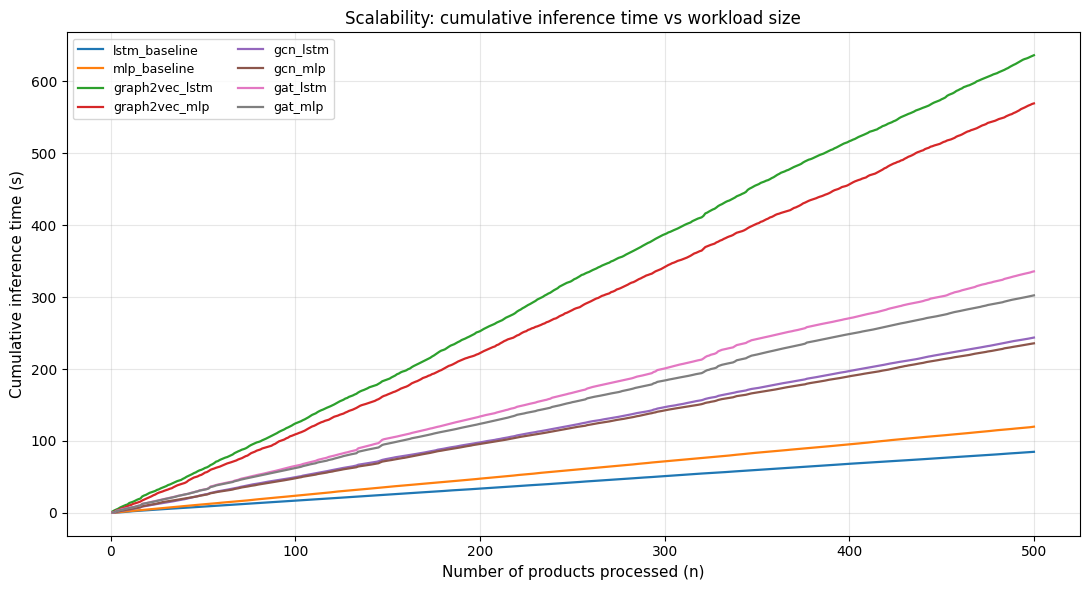

In [23]:
line_plot(
    "cum_infer_s",
    "Cumulative inference time (s)",
    "Scalability: cumulative inference time vs workload size",
    "cum_infer_evolution",
)

## 3. Average graph build time per model

Saved c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\build_time_summary.csv



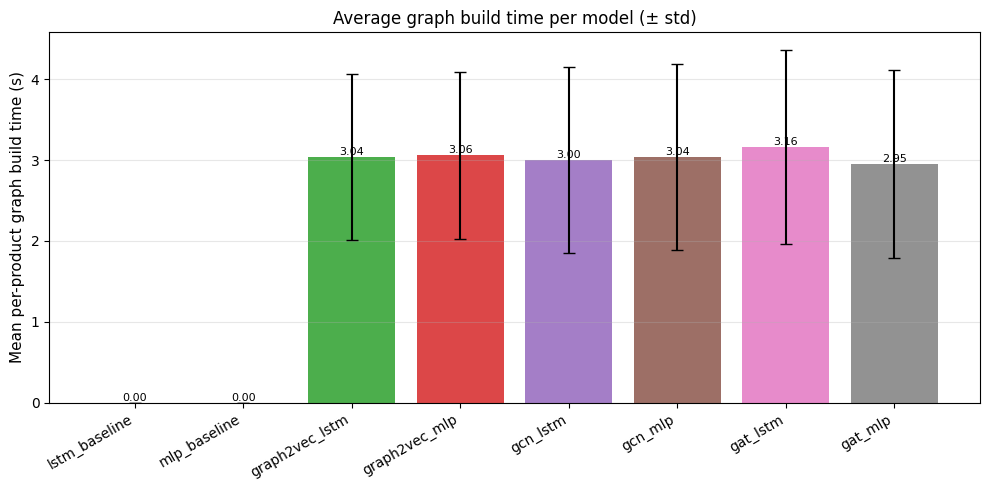

,variant,mean_build_s,std_build_s,total_build_s,n_products
0,lstm_baseline,0.0000,0.0000,0.000,500
1,mlp_baseline,0.0000,0.0000,0.000,500
2,graph2vec_lstm,3.0388,1.0254,1519.416,500
3,graph2vec_mlp,3.0598,1.0322,1529.923,500
4,gcn_lstm,3.0026,1.1492,1501.282,500
5,gcn_mlp,3.0426,1.1488,1521.294,500
6,gat_lstm,3.1635,1.1996,1581.769,500
7,gat_mlp,2.9509,1.1636,1475.451,500


In [24]:
build = (df.groupby("variant")["build_s"]
           .agg(mean_build_s="mean", std_build_s="std",
                total_build_s="sum", n_products="count")
           .reindex(variants)
           .reset_index())
build_csv = os.path.join(HERE, "build_time_summary.csv")
build.round(4).to_csv(build_csv, index=False)
print(f"Saved {build_csv}\n")

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(build["variant"], build["mean_build_s"],
              yerr=build["std_build_s"].fillna(0), capsize=4,
              color=[colors[v] for v in build["variant"]], alpha=0.85)
ax.set_ylabel("Mean per-product graph build time (s)", fontsize=11)
ax.set_title("Average graph build time per model (± std)", fontsize=12)
ax.grid(True, axis="y", alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
for b, v in zip(bars, build["mean_build_s"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{v:.2f}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(HERE, f"mean_build_time.{ext}"), dpi=150, bbox_inches="tight")
plt.show()
build.round(4)

## 4. Epochs analysis &mdash; mean epochs per product & average time per epoch

Two quantities, per model:
- **mean epochs/product** = `mean(epochs_trained)` over the products of that variant.
- **avg time per epoch**, reported two ways:
  - *aggregate (weighted)* = `sum(train_s) / sum(epochs_trained)` &mdash; robust, weights long-training products more.
  - *per-product mean* = `mean(s_per_epoch)` &mdash; the unweighted average of each product's own rate.

If `results1.csv` lacks the epoch columns, we fall back to `results.csv` (which logs them) so the
numbers are real; the printed source tells you which file was used.

In [25]:
EPOCH_COLS = {"epochs_trained", "s_per_epoch"}

if EPOCH_COLS.issubset(df.columns):
    epoch_df = df
    epoch_src = os.path.basename(CSV)
else:
    # results1.csv has no epoch measurements yet -> use results.csv, which does.
    # Delete this fallback (and just use `df`) once epochs are logged in results1.csv.
    _fallback = os.path.join(HERE, "scalability_results.csv")
    epoch_df = pd.read_csv(_fallback)
    epoch_src = os.path.basename(_fallback) + "  (FALLBACK: results1.csv has no epoch columns)"

print(f"Epochs analysis source: {epoch_src}")

# A product is one training run; build_s == 0 rows are still valid training rows.
epochs = (epoch_df.groupby("variant")
            .apply(lambda g: pd.Series({
                "mean_epochs_per_product": g["epochs_trained"].mean(),
                "std_epochs_per_product":  g["epochs_trained"].std(),
                "avg_s_per_epoch_weighted": g["train_s"].sum() / max(g["epochs_trained"].sum(), 1),
                "avg_s_per_epoch_mean":     g["s_per_epoch"].mean(),
                "n_products":               len(g),
            }))
            .reindex([v for v in variants if v in epoch_df["variant"].unique()])
            .reset_index())

epochs_csv = os.path.join(HERE, "epochs_summary.csv")
epochs.round(4).to_csv(epochs_csv, index=False)
print(f"Saved {epochs_csv}\n")
epochs.round(3)

Epochs analysis source: scalability_results.csv
Saved c:\Users\Andre Silva\Desktop\Dissertation25-26\GNN\DynamicSimilarities\Scalability Analysis\epochs_summary.csv



C:\Users\Andre Silva\AppData\Local\Temp\ipykernel_26964\3475643673.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,variant,mean_epochs_per_product,std_epochs_per_product,avg_s_per_epoch_weighted,avg_s_per_epoch_mean,n_products
0,lstm_baseline,145.512,53.732,0.056,0.057,500.0
1,mlp_baseline,155.832,91.672,0.077,0.078,500.0
2,graph2vec_lstm,137.354,39.028,0.329,0.329,500.0
3,graph2vec_mlp,189.994,116.042,0.360,0.363,500.0
4,gcn_lstm,127.294,25.096,0.471,0.468,500.0
5,gcn_mlp,169.888,105.016,0.528,0.518,500.0
6,gat_lstm,124.500,22.766,0.818,0.794,500.0
7,gat_mlp,159.698,87.048,0.881,0.824,500.0


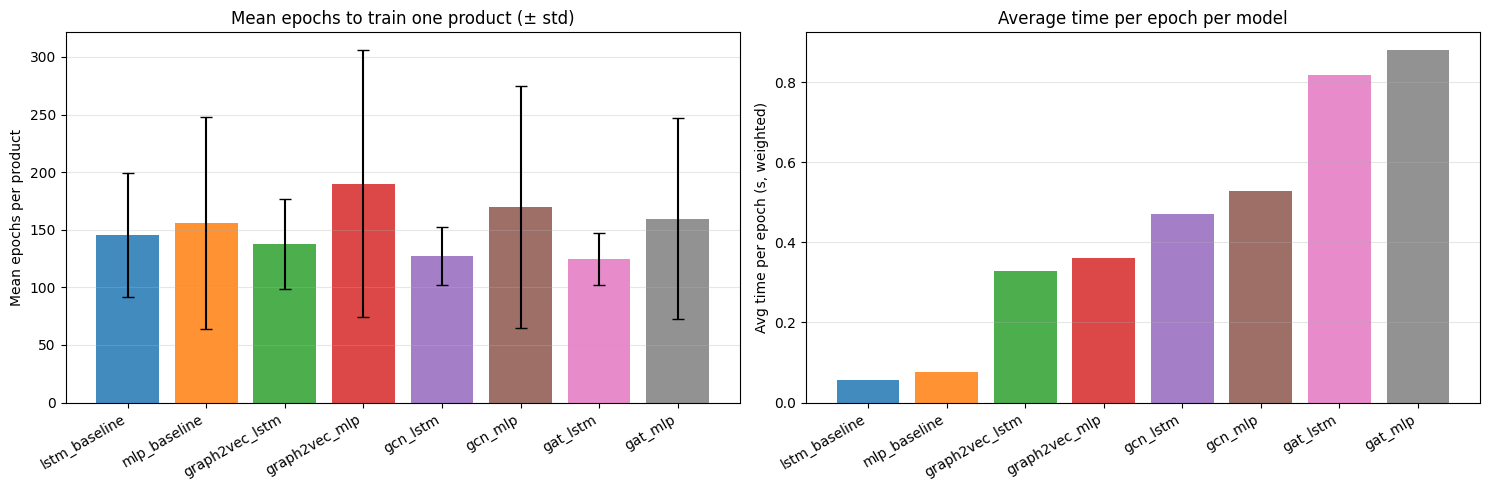

In [26]:
# Visualise the two epoch metrics side by side.
ev = [v for v in variants if v in epochs["variant"].values]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(epochs["variant"], epochs["mean_epochs_per_product"],
            yerr=epochs["std_epochs_per_product"].fillna(0), capsize=4,
            color=[colors[v] for v in epochs["variant"]], alpha=0.85)
axes[0].set_ylabel("Mean epochs per product")
axes[0].set_title("Mean epochs to train one product (± std)")
axes[0].grid(True, axis="y", alpha=0.3)
plt.setp(axes[0].get_xticklabels(), rotation=30, ha="right")

axes[1].bar(epochs["variant"], epochs["avg_s_per_epoch_weighted"],
            color=[colors[v] for v in epochs["variant"]], alpha=0.85)
axes[1].set_ylabel("Avg time per epoch (s, weighted)")
axes[1].set_title("Average time per epoch per model")
axes[1].grid(True, axis="y", alpha=0.3)
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(os.path.join(HERE, f"epochs_analysis.{ext}"), dpi=150, bbox_inches="tight")
plt.show()